# Chapter 6: Case Study 2

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys 
import regex as re 
from glob import glob
import tomli
import os

## Step 1: Run snipseq on IME FACS dataset
#The scripts used to run snipseq is located in the scripts/ directory. 

## Step 2: Preprocessing of Snipseq outputs

In [ ]:
dfs = []
for i in glob("results/snipseq/facs/*_1_ss_assign_ret.csv"):
    df = pd.read_csv(i)
    dfs.append(df)

ss_ret = pd.concat(dfs)

In [ ]:
srr_map = {
    'SRR30861028': ('G1', '1'),
    'SRR30861027': ('G2', '1'),
    'SRR30861026': ('G3', '1'),
    'SRR30861025': ('R1', '1'),
    'SRR30861024': ('R2', '1'),
    'SRR30861023': ('R3', '1'),
    'SRR30861022': ('G1', '2'),
    'SRR30861021': ('G2', '2'),
    'SRR30861020': ('G3', '2'),
    'SRR30861019': ('R1', '2'),
    'SRR30861018': ('R2', '2'),
    'SRR30861017': ('R3', '2'),
}

ss_ret['srr'] = ss_ret['read_id'].str.split('.', n=1, expand=True)[0]

mapped = ss_ret['srr'].map(srr_map)
ss_ret[['sort', 'replicate']] = pd.DataFrame(mapped.tolist(), index=ss_ret.index)
ss_ret = ss_ret.rename(columns={'feature':'Barcode'})
ss_ret['pair'] = ss_ret['pair'].replace({'dtom': 'dTom','gfp_s': 'GFP','gfp_uns': 'unspliced'})
ss_ret['sample'] = ss_ret.sort + '_rep' + ss_ret.replicate + '_' + ss_ret.pair
ss_ret['source'] = 'ss'
# ss_ret.to_csv('results/snipseq/facs/snipseq_full_output.csv', index=False)

ss_ret_matrix = (ss_ret.pivot_table(index='Barcode',columns='sample',values='read_id',aggfunc='size',fill_value=0).rename_axis(index='Barcode').reset_index())
# ss_ret_matrix.to_csv('results/snipseq/facs/snipseq_matrix.csv', index=False)

## Step 3: Loading Snipseq and IME study's results

### Load preprocessed Snipseq output

In [3]:
ss_ret_matrix = pd.read_csv('/home/chiga034/projects_limgroup/gab/2026/ime/results/snipseq/facs/snipseq_matrix.csv')
ss_ret_matrix.shape

(296273, 37)

In [4]:
#Find barcodes that pass the minimum read count threshold (at least 10 GFP and 10 dTom reads in at least 3 samples)
df = ss_ret_matrix.copy()
# --- Assume `df` is your DataFrame with the columns you listed ---
# Ensure numeric dtype for count columns (coerce non-numeric to NaN -> 0)
count_cols = [c for c in df.columns if c != 'Barcode']
df[count_cols] = df[count_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Identify base sample names by stripping the final suffix (_GFP, _dTom, _unspliced)
suffixes = ('_GFP', '_dTom', '_unspliced')
all_samples = sorted({ c.rsplit('_', 1)[0] for c in df.columns if c.endswith(suffixes) })

# Keep only samples that actually have the necessary columns
# (We expect all three, but this is robust to missing ones; unspliced will default to 0 if missing)
valid_samples = []
for s in all_samples:
    has_dtom = f'{s}_dTom' in df.columns
    has_gfp  = f'{s}_GFP' in df.columns
    has_unsp = f'{s}_unspliced' in df.columns
    if has_dtom and (has_gfp or has_unsp):
        valid_samples.append(s)

# Build per-sample GFP and dTom count matrices
gfp_counts = pd.DataFrame(
    {
        s: df.get(f'{s}_GFP', 0).fillna(0).astype(int) + df.get(f'{s}_unspliced', 0).fillna(0).astype(int)
        for s in valid_samples
    },
    index=df.index
)

dtom_counts = pd.DataFrame(
    {
        s: df.get(f'{s}_dTom', 0).fillna(0).astype(int)
        for s in valid_samples
    },
    index=df.index
)

# Apply thresholds: GFP >= 10 AND dTom >= 10 per sample
gfp_ok   = gfp_counts >= 10
dtom_ok  = dtom_counts >= 10
pass_both = gfp_ok & dtom_ok  # True if both thresholds met in that sample

# Count qualifying samples per barcode
min_samples = 3  # "more than 3 samples" => 4. Change to 3 if you meant "at least 3".
pass_count = pass_both.sum(axis=1)

# Filter barcodes
mask_keep = pass_count >= min_samples
filtered_ss = df.loc[mask_keep].copy()

# (Optional) add diagnostics: how many and which samples passed per barcode
samples_meeting = pass_both.apply(lambda row: [s for s, ok in row.items() if ok], axis=1)
filtered_ss['n_samples_meeting_threshold'] = pass_count[mask_keep]
filtered_ss['samples_meeting_threshold'] = samples_meeting[mask_keep].apply(lambda lst: ','.join(lst))

# The resulting barcodes:
kept_barcodes = filtered_ss['Barcode'].tolist()
print(f"Kept {len(kept_barcodes)} barcodes with ≥10 GFP and ≥10 dTom in ≥{min_samples} samples.")

Kept 6727 barcodes with ≥10 GFP and ≥10 dTom in ≥3 samples.


In [5]:
filtered_ss = filtered_ss[['Barcode', 'G1_rep1_GFP', 'G2_rep1_GFP', 'G3_rep1_GFP', 'R1_rep1_GFP',
       'R2_rep1_GFP', 'R3_rep1_GFP', 'G1_rep2_GFP', 'G2_rep2_GFP',
       'G3_rep2_GFP', 'R1_rep2_GFP', 'R2_rep2_GFP', 'R3_rep2_GFP',
       'G1_rep1_dTom', 'G2_rep1_dTom', 'G3_rep1_dTom', 'R1_rep1_dTom',
       'R2_rep1_dTom', 'R3_rep1_dTom', 'G1_rep2_dTom', 'G2_rep2_dTom',
       'G3_rep2_dTom', 'R1_rep2_dTom', 'R2_rep2_dTom', 'R3_rep2_dTom',
       'G1_rep1_unspliced', 'G2_rep1_unspliced', 'G3_rep1_unspliced',
       'R1_rep1_unspliced', 'R2_rep1_unspliced', 'R3_rep1_unspliced',
       'G1_rep2_unspliced', 'G2_rep2_unspliced', 'G3_rep2_unspliced',
       'R1_rep2_unspliced', 'R2_rep2_unspliced', 'R3_rep2_unspliced']]

# Extra filtering to make sure no Gs in the Barcodes.
filtered_ss = filtered_ss[~filtered_ss.Barcode.str.contains('G')]

In [6]:
# Keep Barcode as id; melt all other columns
id_cols = ['Barcode']
value_cols = [c for c in filtered_ss.columns if c not in id_cols]

ss_long = filtered_ss.melt(
    id_vars=id_cols,
    value_vars=value_cols,
    var_name='measurement',
    value_name='counts'
)

# Split 'G1_rep1_GFP' into ['G1', 'rep1', 'GFP'] using simple string ops
parts = ss_long['measurement'].str.split('_', n=2, expand=True)
parts.columns = ['sort', 'rep_token', 'pair']

# Convert rep_token like 'rep1' -> 1 without regex
parts['replicate'] = parts['rep_token'].str.replace('rep', '', regex=False).astype('int64')

# Assemble tidy DataFrame
ss_long = pd.concat([ss_long.drop(columns=['measurement']), parts[['sort', 'replicate', 'pair']]],axis=1)

ss_long = ss_long[['Barcode', 'sort', 'replicate', 'pair', 'counts']]
ss_long['source'] = 'ss'

### Load IME study FACS results

In [7]:
kw = pd.read_csv('/home/chiga034/projects_limgroup/gab/2026/ime/metadata/S6_FACS_readcounts-Table 1.csv')
kw.shape

(38163, 37)

In [21]:
df = kw.copy()
# --- Assume `df` is your DataFrame with the columns you listed ---
# Ensure numeric dtype for count columns (coerce non-numeric to NaN -> 0)
count_cols = [c for c in df.columns if c != 'Barcode']
df[count_cols] = df[count_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# Identify base sample names by stripping the final suffix (_GFP, _dTom, _unspliced)
suffixes = ('_GFP', '_dTom', '_unspliced')
all_samples = sorted({ c.rsplit('_', 1)[0] for c in df.columns if c.endswith(suffixes) })

# Keep only samples that actually have the necessary columns
# (We expect all three, but this is robust to missing ones; unspliced will default to 0 if missing)
valid_samples = []
for s in all_samples:
    has_dtom = f'{s}_dTom' in df.columns
    has_gfp  = f'{s}_GFP' in df.columns
    has_unsp = f'{s}_unspliced' in df.columns
    if has_dtom and (has_gfp or has_unsp):
        valid_samples.append(s)

# Build per-sample GFP and dTom count matrices
gfp_counts = pd.DataFrame(
    {
        s: df.get(f'{s}_GFP', 0).fillna(0).astype(int) + df.get(f'{s}_unspliced', 0).fillna(0).astype(int)
        for s in valid_samples
    },
    index=df.index
)

dtom_counts = pd.DataFrame(
    {
        s: df.get(f'{s}_dTom', 0).fillna(0).astype(int)
        for s in valid_samples
    },
    index=df.index
)

# Apply thresholds: GFP >= 10 AND dTom >= 10 per sample
gfp_ok   = gfp_counts >= 10
dtom_ok  = dtom_counts >= 10
pass_both = gfp_ok & dtom_ok  # True if both thresholds met in that sample

# Count qualifying samples per barcode
min_samples = 3  # "more than 3 samples" => 4. Change to 3 if you meant "at least 3".
pass_count = pass_both.sum(axis=1)

# Filter barcodes
mask_keep = pass_count >= min_samples
filtered_kw = df.loc[mask_keep].copy()

# (Optional) add diagnostics: how many and which samples passed per barcode
samples_meeting = pass_both.apply(lambda row: [s for s, ok in row.items() if ok], axis=1)
filtered_kw['n_samples_meeting_threshold'] = pass_count[mask_keep]
filtered_kw['samples_meeting_threshold'] = samples_meeting[mask_keep].apply(lambda lst: ','.join(lst))

# The resulting barcodes:
kept_barcodes = filtered_kw['Barcode'].tolist()
print(f"Kept {len(kept_barcodes)} barcodes with ≥10 GFP and ≥10 dTom in ≥{min_samples} samples.")

Kept 4572 barcodes with ≥10 GFP and ≥10 dTom in ≥3 samples.


In [22]:
filtered_kw = filtered_kw[['Barcode', 'G1_rep1_GFP', 'G2_rep1_GFP', 'G3_rep1_GFP', 'R1_rep1_GFP',
       'R2_rep1_GFP', 'R3_rep1_GFP', 'G1_rep2_GFP', 'G2_rep2_GFP',
       'G3_rep2_GFP', 'R1_rep2_GFP', 'R2_rep2_GFP', 'R3_rep2_GFP',
       'G1_rep1_dTom', 'G2_rep1_dTom', 'G3_rep1_dTom', 'R1_rep1_dTom',
       'R2_rep1_dTom', 'R3_rep1_dTom', 'G1_rep2_dTom', 'G2_rep2_dTom',
       'G3_rep2_dTom', 'R1_rep2_dTom', 'R2_rep2_dTom', 'R3_rep2_dTom',
       'G1_rep1_unspliced', 'G2_rep1_unspliced', 'G3_rep1_unspliced',
       'R1_rep1_unspliced', 'R2_rep1_unspliced', 'R3_rep1_unspliced',
       'G1_rep2_unspliced', 'G2_rep2_unspliced', 'G3_rep2_unspliced',
       'R1_rep2_unspliced', 'R2_rep2_unspliced', 'R3_rep2_unspliced']]

In [23]:
# There are 5 barcodes with G from the IME study FACS results
print(f"Number of barcodes with G from the IME study FACS results: {filtered_kw[filtered_kw.Barcode.str.contains('G')]['Barcode'].nunique()}")

# Excluded these barcodes so that it is consistent
filtered_kw = filtered_kw[~filtered_kw.Barcode.str.contains('G')]

Number of barcodes with G from the IME study FACS results: 5


In [24]:
# Keep Barcode as id; melt all other columns
id_cols = ['Barcode']
value_cols = [c for c in filtered_kw.columns if c not in id_cols]

kw_long = filtered_kw.melt(
    id_vars=id_cols,
    value_vars=value_cols,
    var_name='measurement',
    value_name='counts'
)

# Split 'G1_rep1_GFP' into ['G1', 'rep1', 'GFP'] using simple string ops
parts = kw_long['measurement'].str.split('_', n=2, expand=True)
parts.columns = ['sort', 'rep_token', 'pair']

# Convert rep_token like 'rep1' -> 1 without regex
parts['replicate'] = parts['rep_token'].str.replace('rep', '', regex=False).astype('int64')

# Assemble tidy DataFrame
kw_long = pd.concat([kw_long.drop(columns=['measurement']), parts[['sort', 'replicate', 'pair']]],axis=1)

kw_long = kw_long[['Barcode', 'sort', 'replicate', 'pair', 'counts']]
kw_long['source'] = 'kw'

## Step 4: Preparing dataframe for plotting

In [25]:
df_long = pd.concat([ss_long, kw_long])
df_long['pair'] = df_long['pair'].replace({'unspliced':'GFP_uns'})
df_long['source'] = df_long['source'].replace({'kw':'Kowal','ss':'Snipseq'})

In [26]:
# The barcode-intron dictionary from the IME study
s4 = pd.read_csv('/home/chiga034/projects_limgroup/gab/2026/ime/metadata/kowal_s4.csv')
s4 = s4.rename(columns={'Unnamed: 0':'Barcode'})

In [27]:
print(f"Number of barcodes that contain a 'G': {s4[s4.Barcode.str.contains('G')]['Barcode'].nunique()}")

print(f"Number of barcodes that contain an 'AUG': {s4[s4.Barcode.str.contains('ATG')]['Barcode'].nunique()}")

Number of barcodes that contain a 'G': 12
Number of barcodes that contain an 'AUG': 2


In [28]:
# Remove barcodes with G
s4 = s4[~s4.Barcode.str.contains('G')]

In [29]:
# Barcodes that pass minimum requirements and merged with the barcode-intron dictionary
df_long_s4 = pd.merge(df_long, s4, on='Barcode')

In [33]:
df_sum_s4 = df_long_s4.groupby(['source','sort','replicate','pair'], as_index=False)['counts'].sum()
df_sum_s4.loc[df_sum_s4['sort'].str.contains('G'), 'reporter'] = 'Green'
df_sum_s4.loc[~df_sum_s4['sort'].str.contains('G'), 'reporter'] = 'Red'

### Figure 6.5(A)

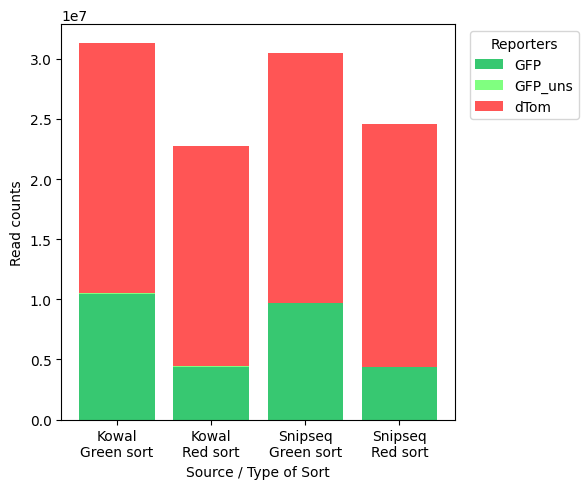

In [34]:
wide_s4 = (df_sum_s4.pivot_table(index=['source', 'reporter'],
                            columns='pair',
                            values='counts',
                            aggfunc='sum',
                            fill_value=0)
                 .sort_index())

pairs = list(wide_s4.columns)
color_map = {'dTom': '#ff5555', 'GFP': '#37c871', 'GFP_uns': '#80ff80'}

labels = [f'{s}\n{r} sort' for s, r in wide_s4.index]
x = range(len(wide_s4))

fig, ax = plt.subplots(figsize=(max(6, len(wide_s4)*0.8), 5))
bottom = [0] * len(wide_s4)
for p in pairs:
    vals = wide_s4[p].values
    ax.bar(x, vals, bottom=bottom, label=p, color=color_map[p])
    bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=0)
ax.set_xlabel('Source / Type of Sort')
ax.set_ylabel('Read counts')
ax.legend(title='Reporters', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
# plt.savefig('results/snipseq/facs/figures/proportions_of_reporters_per_sort_merged_with_bi.png',dpi=300,bbox_inches='tight')
# plt.savefig('results/snipseq/facs/figures/proportions_of_reporters_per_sort_merged_with_bi.pdf',dpi=300,bbox_inches='tight')
plt.show()

### Figure 6.5(B)

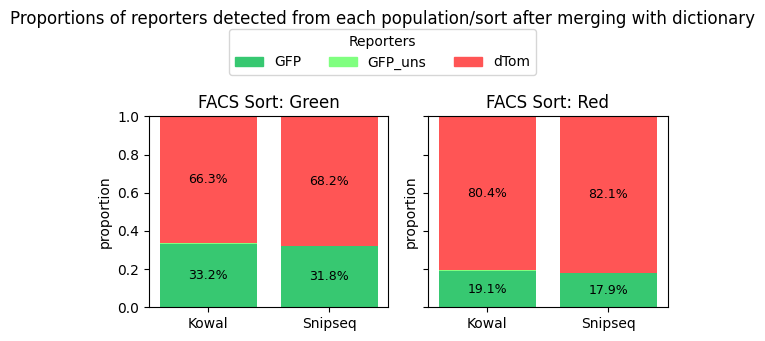

In [35]:
prop = wide_s4.div(wide_s4.sum(axis=1), axis=0).fillna(0)
pairs = list(wide_s4.columns)
color_map = {'dTom': '#ff5555', 'GFP': '#37c871', 'GFP_uns': '#80ff80'}
reporters = wide_s4.index.get_level_values('reporter').unique()

# --- proportions only: one row of subplots ---
n_cols = len(reporters)
fig, axes = plt.subplots(1, n_cols, figsize=(6, 3), sharex=False, sharey=True)

# Make axes indexable even if there's just one reporter
if n_cols == 1:
    axes = [axes]

for col, rep in enumerate(reporters):
    axp = axes[col]
    subp = prop.xs(rep, level='reporter')
    x = range(len(subp))
    bottom = [0.0] * len(subp)

    for p in pairs:
        vals = subp[p].values
        axp.bar(x, vals, bottom=bottom, label=p, color=color_map[p])
        # add % labels for segments >= 3%
        for xi, v, b in zip(x, vals, bottom):
            if v >= 0.03:
                axp.text(xi, b + v / 2, f'{v * 100:.1f}%', ha='center', va='center', fontsize=9)
        bottom = [b + v for b, v in zip(bottom, vals)]

    axp.set_title(f'FACS Sort: {rep}')
    axp.set_xticks(list(x))
    axp.set_xticklabels(subp.index, rotation=0)
    axp.set_ylabel('proportion')
    axp.set_ylim(0, 1)

# single legend across the top
handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[p]) for p in pairs]
fig.legend(handles, pairs, title='Reporters', loc='upper center', ncol=min(len(pairs), 6), bbox_to_anchor=(0.5, 1.08))

fig.suptitle('Proportions of reporters detected from each population/sort after merging with dictionary', y=1.12)
plt.tight_layout()
# plt.savefig('results/snipseq/facs/figures/proportions_of_reporters_per_sort_percentage_merged_with_bi.png',dpi=300,bbox_inches='tight')
# plt.savefig('results/snipseq/facs/figures/proportions_of_reporters_per_sort_percentage_merged_with_bi_percentage.pdf',dpi=300,bbox_inches='tight')
plt.show()